# Attribution Targets API

<a target="_blank" href="https://colab.research.google.com/github/safety-research/circuit-tracer/blob/main/demos/attribution_targets_demo.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This tutorial explores how to use the **attribution targets API** to attribute back from arbitrary tokens or functions thereof. The `AttributionTargets` class (in `circuit_tracer.attribution.targets`) accepts four input formats:

1. **`None`** — *Salient logits* (default): auto-select the most probable next tokens via `max_n_logits` / `desired_logit_prob`
2. **`Sequence[str]`** — *Token strings*: attribute from explicitly named tokens (e.g., `["▁Austin", "▁Dallas"]`)
3. **`Sequence[TargetSpec]`** — *Custom targets*: attribute from an arbitrary direction in the residual stream (e.g., a `CustomTarget` encoding `logit(Austin) − logit(Dallas)`)
4. **`torch.Tensor`** — *Token ID tensor*: attribute from specific vocabulary indices

We use the capital-city prompt from the other demos: the model must resolve *"capital of the state containing Dallas"* via multi-hop reasoning (Dallas → Texas → Austin).

After comparing the top features discovered under each mode, we run some relevant causal interventions.

In [1]:
# @title Colab Setup Environment

try:
    import google.colab

    !mkdir -p repository && cd repository && \
     git clone https://github.com/safety-research/circuit-tracer && \
     curl -LsSf https://astral.sh/uv/install.sh | sh && \
     uv pip install -e circuit-tracer/

    import sys
    from huggingface_hub import notebook_login

    sys.path.append("repository/circuit-tracer")
    sys.path.append("repository/circuit-tracer/demos")
    notebook_login(new_session=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
from functools import partial

import torch

from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.attribution.targets import CustomTarget
from circuit_tracer.utils import create_graph_files
from circuit_tracer.utils.demo_utils import (
    cleanup_cuda,
    display_ablation_chart,
    display_token_probs,
    display_topk_token_predictions,
    display_top_features_comparison,
    get_top_features,
    get_unembed_vecs,
)

/mnt/cache/speediedan/.venvs/ct_dev/lib/python3.13/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Setup

Load the model and define helper functions. We use `google/gemma-2-2b` with the Gemma Scope transcoders, the same configuration used in the other demos. Change `backend` to `'nnsight'` if you prefer the NNSight backend.

In [3]:
model_name = "google/gemma-2-2b"
transcoder_name = "gemma"
backend = "transformerlens"  # change to 'nnsight' for the nnsight backend!
model = ReplacementModel.from_pretrained(
    model_name, transcoder_name, dtype=torch.bfloat16, backend=backend
)

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


We'll also define a small helper to build a `CustomTarget` that represents the direction `logit(Austin) − logit(Dallas)` in the residual stream. This composes two columns of the unembedding matrix into a single direction vector, weighted by the absolute softmax probability difference between the two tokens.

In [4]:
def _get_last_position_probs(model, prompt):
    """Get softmax probabilities at the last token position."""
    input_ids = model.ensure_tokenized(prompt)
    with torch.no_grad():
        logits, _ = model.get_activations(input_ids)
    return torch.softmax(logits.squeeze(0)[-1], dim=-1)


def build_custom_diff_target(model, prompt, token_x, token_y, backend):
    """Build a CustomTarget for the direction logit(token_x) − logit(token_y).

    Returns (custom_target, idx_x, idx_y).
    """
    tokenizer = model.tokenizer
    idx_x = tokenizer.encode(token_x, add_special_tokens=False)[-1]
    idx_y = tokenizer.encode(token_y, add_special_tokens=False)[-1]

    # Extract unembed columns (backend-agnostic)
    vec_x, vec_y = get_unembed_vecs(model, [idx_x, idx_y], backend)
    diff_vec = vec_x - vec_y

    # Weight = |p(token_x) − p(token_y)|, floored at 1e-6
    probs = _get_last_position_probs(model, prompt)
    diff_prob = max((probs[idx_x] - probs[idx_y]).abs().item(), 1e-6)

    custom_target = CustomTarget(
        token_str=f"logit({token_x})-logit({token_y})",
        prob=diff_prob,
        vec=diff_vec,
    )
    return custom_target, idx_x, idx_y


def build_semantic_concept_target(model, prompt, group_a_tokens, group_b_tokens, label, backend):
    """Build a CustomTarget for an abstract concept direction via vector rejection.

    For each (capital, state) pair, project the capital vector onto the state
    vector and subtract that projection.  The residual is the component of
    "capital-ness" orthogonal to its state, stripping out shared geography.

        v_residual_i = v_cap_i − proj_{v_state_i}(v_cap_i)

    The final direction is the mean of these residuals.

    Returns CustomTarget.
    """
    assert len(group_a_tokens) == len(group_b_tokens), "Groups must have equal length for paired differences"
    tokenizer = model.tokenizer
    ids_a = [tokenizer.encode(t, add_special_tokens=False)[-1] for t in group_a_tokens]
    ids_b = [tokenizer.encode(t, add_special_tokens=False)[-1] for t in group_b_tokens]

    vecs_a = get_unembed_vecs(model, ids_a, backend)
    vecs_b = get_unembed_vecs(model, ids_b, backend)

    # Vector rejection: for each pair, remove the state-direction component
    residuals = []
    for va, vb in zip(vecs_a, vecs_b):
        va_f, vb_f = va.float(), vb.float()
        proj = (va_f @ vb_f) / (vb_f @ vb_f) * vb_f      # proj_{state}(capital)
        residuals.append((va_f - proj).to(va.dtype))

    direction = torch.stack(residuals).mean(0)

    # Weight = average probability of group-A tokens, floored at 1e-6
    probs = _get_last_position_probs(model, prompt)
    avg_prob = max(sum(probs[i].item() for i in ids_a) / len(ids_a), 1e-6)

    return CustomTarget(token_str=label, prob=avg_prob, vec=direction)

## Attribution Configuration

Define the prompt, shared attribution parameters, and the three target tokens we'll track (`▁Austin`, `▁Dallas`, `▁Texas`). The `CustomTarget` encodes the logit-difference direction `logit(Austin) − logit(Dallas)` in the residual stream.

In [5]:
prompt = "Fact: the capital of the state containing Dallas is"
token_x, token_y = "▁Austin", "▁Dallas"

# Shared attribution kwargs (apply to all runs)
# Note: max_n_logits / desired_logit_prob only apply to salient-logit mode
attr_kwargs = dict(
    batch_size=256,
    max_feature_nodes=8192,
    offload="disk" if IN_COLAB else "cpu",
    verbose=True,
)

# Build the custom diff-target: logit(Austin) − logit(Dallas)
custom_target, idx_x, idx_y = build_custom_diff_target(
    model, prompt, token_x, token_y, backend=backend
)

# Build the semantic concept target: Capital Cities − States
capitals = ["▁Austin", "▁Sacramento", "▁Olympia", "▁Atlanta"]
states   = ["▁Texas", "▁California", "▁Washington", "▁Georgia"]
semantic_target = build_semantic_concept_target(
    model, prompt, capitals, states,
    label="Concept: Capitals − States", backend=backend,
)

# Also track Texas — the intermediate hop in the multi-hop chain
idx_texas = model.tokenizer.encode("▁Texas", add_special_tokens=False)[-1]

# Bind the tokenizer and key tokens for display helpers
display_topk = partial(
    display_topk_token_predictions,
    tokenizer=model.tokenizer,
    key_tokens=[(token_x, idx_x), (token_y, idx_y), ("▁Texas", idx_texas)],
)

# Show baseline token probabilities
input_ids = model.ensure_tokenized(prompt)
with torch.no_grad():
    baseline_logits, _ = model.get_activations(input_ids)

key_ids = [idx_x, idx_y, idx_texas]
key_labels = [token_x, token_y, "▁Texas"]
display_token_probs(baseline_logits, key_ids, key_labels, title="Baseline probabilities")

print(f"\nToken X: {token_x!r}  (vocab id {idx_x})")
print(f"Token Y: {token_y!r}  (vocab id {idx_y})")
print(f"Texas:   '▁Texas'  (vocab id {idx_texas})")
print(f"Custom target: {custom_target.token_str}  prob={custom_target.prob:.4e}")
print(f"Semantic target: {semantic_target.token_str}  prob={semantic_target.prob:.4e}")

Token,Probability,Logit
▁Austin,41.380%,26.1250
▁Dallas,2.998%,23.5000
▁Texas,5.600%,24.1250



Token X: '▁Austin'  (vocab id 22605)
Token Y: '▁Dallas'  (vocab id 26865)
Texas:   '▁Texas'  (vocab id 9447)
Custom target: logit(▁Austin)-logit(▁Dallas)  prob=3.8477e-01
Semantic target: Concept: Capitals − States  prob=1.0557e-01


## Automatic Target Selection — Salient Logits (`None`)

When `attribution_targets` is `None` (the default), `AttributionTargets` auto-selects the most probable next tokens until `desired_logit_prob` cumulative probability is reached (capped at `max_n_logits`). This is the standard mode used by `attribute_demo.ipynb`.

In [6]:
graph_salient = attribute(
    prompt=prompt, model=model,
    max_n_logits=10, desired_logit_prob=0.95,
    **attr_kwargs,
)
print(f"Salient-logits graph: {len(graph_salient.logit_targets)} targets, "
      f"{graph_salient.active_features.shape[0]} active features")

# Free CUDA memory before next run
cleanup_cuda()

Phase 0: Precomputing activations and vectors
Precomputation completed in 0.21s
Found 9152 active features
Phase 1: Running forward pass
Forward pass completed in 0.10s
Phase 2: Building input vectors
Using 10 salient logits with cumulative probability 0.7422
Will include 8192 of 9152 feature nodes
Input vectors built in 1.37s
Phase 3: Computing logit attributions
<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Logit attributions completed in 0.09s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:02<00:00, 4001.74it/s]
Feature attributions completed in 2.05s
Attribution completed in 6.97s


Salient-logits graph: 10 targets, 9152 active features


## Token-String Targets — `Sequence[str]`

Pass a list of token strings (e.g., `["▁Austin", "▁Dallas"]`) to focus attribution on exactly those logits. Internally, each string is tokenized and its softmax probability and unembedding vector are computed automatically — you only need to supply the surface forms.

In [7]:
graph_str = attribute(
    prompt=prompt, model=model,
    attribution_targets=[token_x, token_y],
    **attr_kwargs,
)
print(f"String-targets graph: {len(graph_str.logit_targets)} targets, "
      f"{graph_str.active_features.shape[0]} active features")

# Free CUDA memory before next run
cleanup_cuda()

Phase 0: Precomputing activations and vectors
Precomputation completed in 0.18s
Found 9152 active features
Phase 1: Running forward pass
Forward pass completed in 0.09s
Phase 2: Building input vectors
Using 2 specified logit targets with cumulative probability 0.4434
Will include 8192 of 9152 feature nodes
Input vectors built in 1.35s
Phase 3: Computing logit attributions
Logit attributions completed in 0.05s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:02<00:00, 3998.39it/s]
Feature attributions completed in 2.05s
Attribution completed in 6.96s


String-targets graph: 2 targets, 9152 active features


## Custom Logit-Difference Target — `Sequence[TargetSpec]`

Pass a `CustomTarget` (or any `TargetSpec` — a tuple of `(token_str, prob, vec)`) that encodes an arbitrary direction in the residual stream. Here the direction is `logit(Austin) − logit(Dallas)`, so attribution will trace the circuit that drives the *correct* answer over the surface-level attractor, rather than tracing individual logit values separately.

In [8]:
graph_custom = attribute(
    prompt=prompt, model=model,
    attribution_targets=[custom_target],
    **attr_kwargs,
)
print(f"Custom-target graph: {len(graph_custom.logit_targets)} targets, "
      f"{graph_custom.active_features.shape[0]} active features")

Phase 0: Precomputing activations and vectors
Precomputation completed in 0.18s
Found 9152 active features
Phase 1: Running forward pass
Forward pass completed in 0.08s
Phase 2: Building input vectors
Using 1 custom attribution targets with total weight 0.3848
Will include 8192 of 9152 feature nodes
Input vectors built in 1.34s
Phase 3: Computing logit attributions
Logit attributions completed in 0.05s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:02<00:00, 3929.05it/s]
Feature attributions completed in 2.09s
Attribution completed in 7.08s


Custom-target graph: 1 targets, 9152 active features


## Semantic Direction — Concept Target

Instead of a pairwise logit difference, we can attribute to an **abstract concept direction** in the residual stream. We build a CustomTarget for an abstract concept direction via vector rejection. For each (capital, state) pair, project the capital vector onto the state vector and subtract that projection, leaving pure "capital-ness".

In [9]:
graph_semantic = attribute(
    prompt=prompt, model=model,
    attribution_targets=[semantic_target],
    **attr_kwargs,
)
print(f"Semantic-target graph: {len(graph_semantic.logit_targets)} targets, "
      f"{graph_semantic.active_features.shape[0]} active features")

# Free CUDA memory before feature comparison
cleanup_cuda()

Phase 0: Precomputing activations and vectors
Precomputation completed in 0.14s
Found 9152 active features
Phase 1: Running forward pass
Forward pass completed in 0.08s
Phase 2: Building input vectors
Using 1 custom attribution targets with total weight 0.1056
Will include 8192 of 9152 feature nodes
Input vectors built in 1.34s
Phase 3: Computing logit attributions
Logit attributions completed in 0.05s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:02<00:00, 4067.53it/s]
Feature attributions completed in 2.02s
Attribution completed in 6.83s


Semantic-target graph: 1 targets, 9152 active features


## Compare Top Features

Extract the top-10 features from each graph (ranked by multi-hop influence) and display them side by side. Feature indices link to their [Neuronpedia](https://www.neuronpedia.org/) dashboards. The *Custom Target* column highlights features that specifically drive the Austin-vs-Dallas logit difference — the multi-hop reasoning circuit (Dallas → Texas → capital → Austin).

In [10]:
top_salient, scores_salient   = get_top_features(graph_salient,  n=10)
top_str, scores_str           = get_top_features(graph_str,      n=10)
top_custom, scores_custom     = get_top_features(graph_custom,   n=10)
top_semantic, scores_semantic = get_top_features(graph_semantic,  n=10)

display_top_features_comparison(
    {
        "Salient Logits": top_salient,
        f"Strings [{token_x}, {token_y}]": top_str,
        f"Custom ({custom_target.token_str})": top_custom,
        f"Semantic ({semantic_target.token_str})": top_semantic,
    },
    scores_sets={
        "Salient Logits": scores_salient,
        f"Strings [{token_x}, {token_y}]": scores_str,
        f"Custom ({custom_target.token_str})": scores_custom,
        f"Semantic ({semantic_target.token_str})": scores_semantic,
    },
    neuronpedia_model="gemma-2-2b",
)

#,Node,Score
1,"(20, 10, 15589)",0.0197
2,"(24, 10, 6044)",0.0159
3,"(21, 10, 5943)",0.0118
4,"(23, 10, 12237)",0.0083
5,"(14, 9, 2268)",0.0080
6,"(16, 9, 25)",0.0074
7,"(25, 10, 13300)",0.0072
8,"(20, 9, 15589)",0.0069
9,"(24, 10, 6394)",0.0061
10,"(24, 10, 13277)",0.0057


## Amplify the Austin-Dallas Custom Difference Circuit

To confirm the custom-target features are causally meaningful, we amplify them by 10× and check that the Austin-vs-Dallas logit gap widens (i.e., the model becomes even more confident Austin is correct).

In [11]:
# Get activations for interventions
input_ids = model.ensure_tokenized(prompt)
original_logits, activations = model.get_activations(input_ids, sparse=True)

# Baseline
display_token_probs(original_logits, key_ids, key_labels, title="Before amplification")

# Amplify top custom-target features by 10×
intervention_tuples = [
    (layer, pos, feat_idx, 10.0 * activations[layer, pos, feat_idx])
    for (layer, pos, feat_idx) in top_custom
]

new_logits, _ = model.feature_intervention(input_ids, intervention_tuples)

display_token_probs(new_logits, key_ids, key_labels, title="After 10× amplification")

orig_gap = (original_logits.squeeze(0)[-1, idx_x] - original_logits.squeeze(0)[-1, idx_y]).item()
new_gap = (new_logits.squeeze(0)[-1, idx_x] - new_logits.squeeze(0)[-1, idx_y]).item()
print(f"\nlogit(Austin) − logit(Dallas): {orig_gap:.4f} → {new_gap:.4f}  (Δ = {new_gap - orig_gap:+.4f})")

display_topk(prompt, original_logits, new_logits)

Token,Probability,Logit
▁Austin,41.380%,26.1250
▁Dallas,2.998%,23.5000
▁Texas,5.600%,24.1250


Token,Probability,Logit
▁Austin,83.206%,24.7500
▁Dallas,5.91e-04,17.5000
▁Texas,5.28e-09,5.8750



logit(Austin) − logit(Dallas): 2.6250 → 7.2500  (Δ = +4.6250)


Token,Probability,Distribution
Austin,0.414,41.4%
Texas,0.056,5.6%
the,0.056,5.6%
not,0.056,5.6%
Fort,0.044,4.4%
Token,Probability,Distribution
Austin,0.832,83.2%
in,0.017,1.7%
AUSTIN,0.010,1.0%
Irving,0.009,0.9%


## Amplify the Semantic Concept Circuit

Same amplification test for the **semantic concept** features. We compare a modest 2× boost (a gentle nudge along the concept axis) with a strong 10× boost to observe the difference in behaviour.

In [12]:
# Baseline
display_token_probs(original_logits, key_ids, key_labels, title="Before amplification (semantic)")

orig_gap = (original_logits.squeeze(0)[-1, idx_x] - original_logits.squeeze(0)[-1, idx_y]).item()

# --- 2× amplification (gentle nudge along the concept axis) ---
sem_amp_tuples_2 = [
    (layer, pos, feat_idx, 2.0 * activations[layer, pos, feat_idx])
    for (layer, pos, feat_idx) in top_semantic
]

sem_amp_logits_2, _ = model.feature_intervention(input_ids, sem_amp_tuples_2)

display_token_probs(sem_amp_logits_2, key_ids, key_labels, title="After 2× amplification (semantic)")

sem_gap_2 = (sem_amp_logits_2.squeeze(0)[-1, idx_x] - sem_amp_logits_2.squeeze(0)[-1, idx_y]).item()
print(f"\nlogit(Austin) − logit(Dallas): {orig_gap:.4f} → {sem_gap_2:.4f}  (Δ = {sem_gap_2 - orig_gap:+.4f})  [2×]")

display_topk(prompt, original_logits, sem_amp_logits_2)

# --- 10× amplification (strong boost) ---
sem_amp_tuples_10 = [
    (layer, pos, feat_idx, 10.0 * activations[layer, pos, feat_idx])
    for (layer, pos, feat_idx) in top_semantic
]

sem_amp_logits_10, _ = model.feature_intervention(input_ids, sem_amp_tuples_10)

display_token_probs(sem_amp_logits_10, key_ids, key_labels, title="After 10× amplification (semantic)")

sem_gap_10 = (sem_amp_logits_10.squeeze(0)[-1, idx_x] - sem_amp_logits_10.squeeze(0)[-1, idx_y]).item()
print(f"\nlogit(Austin) − logit(Dallas): {orig_gap:.4f} → {sem_gap_10:.4f}  (Δ = {sem_gap_10 - orig_gap:+.4f})  [10×]")

display_topk(prompt, original_logits, sem_amp_logits_10)

Token,Probability,Logit
▁Austin,41.380%,26.1250
▁Dallas,2.998%,23.5000
▁Texas,5.600%,24.1250


Token,Probability,Logit
▁Austin,61.581%,26.3750
▁Dallas,3.474%,23.5000
▁Texas,0.470%,21.5000



logit(Austin) − logit(Dallas): 2.6250 → 2.8750  (Δ = +0.2500)  [2×]


Token,Probability,Distribution
Austin,0.414,41.4%
Texas,0.056,5.6%
the,0.056,5.6%
not,0.056,5.6%
Fort,0.044,4.4%
Token,Probability,Distribution
Austin,0.617,61.7%
Dallas,0.035,3.5%
Fort,0.035,3.5%
San,0.031,3.1%


Token,Probability,Logit
▁Austin,65.185%,26.1250
▁Dallas,0.266%,20.6250
▁Texas,2.92e-11,2.2969



logit(Austin) − logit(Dallas): 2.6250 → 5.5000  (Δ = +2.8750)  [10×]


Token,Probability,Distribution
Austin,0.414,41.4%
Texas,0.056,5.6%
the,0.056,5.6%
not,0.056,5.6%
Fort,0.044,4.4%
Token,Probability,Distribution
Austin,0.652,65.2%
San,0.113,11.3%
Austin,0.025,2.5%
Fort,0.025,2.5%


## Ablate the Austin-Dallas Custom Difference Circuit

Now do the opposite: zero out progressively more custom-target features to remove the Austin-driving circuit. With enough of the multi-hop reasoning path suppressed, the model can no longer resolve the correct answer and reverts to nearby concepts — the intermediate state (Texas) rather than its capital.

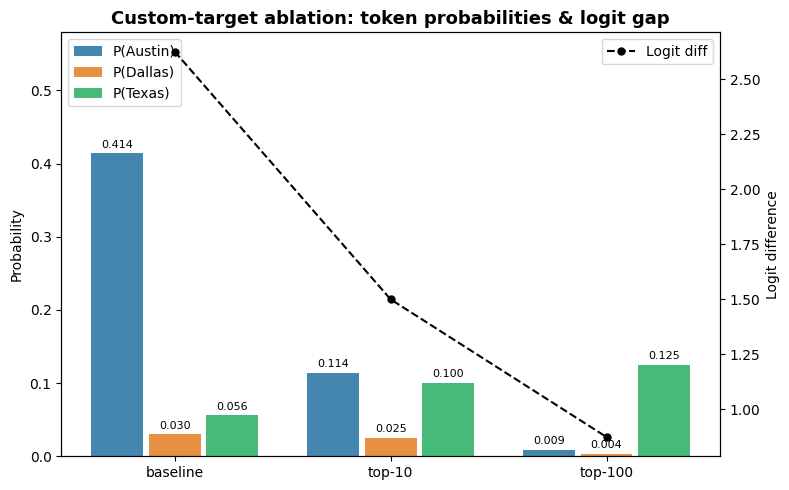


Top-100 ablation — full prediction shift:


Token,Probability,Distribution
Austin,0.414,41.4%
Texas,0.056,5.6%
the,0.056,5.6%
not,0.056,5.6%
Fort,0.044,4.4%
Token,Probability,Distribution
Texas,0.125,12.5%
the,0.110,11.0%
not,0.059,5.9%
called,0.036,3.6%


In [13]:
# Progressive ablation: zero out increasing numbers of custom-target features
probs_base = torch.softmax(original_logits.squeeze(0)[-1].float(), dim=-1)
groups = {"baseline": {
    "P(Austin)": probs_base[idx_x].item(),
    "P(Dallas)": probs_base[idx_y].item(),
    "P(Texas)":  probs_base[idx_texas].item(),
}}
logit_diffs = {"baseline": orig_gap}

ablation_results = {}
for n in [10, 100]:
    top_n, _ = get_top_features(graph_custom, n=n)
    abl_tuples = [
        (layer, pos, feat_idx, 0.0 * activations[layer, pos, feat_idx])
        for (layer, pos, feat_idx) in top_n
    ]
    abl_logits, _ = model.feature_intervention(input_ids, abl_tuples)
    probs_abl = torch.softmax(abl_logits.squeeze(0)[-1].float(), dim=-1)
    gap = (abl_logits.squeeze(0)[-1, idx_x] - abl_logits.squeeze(0)[-1, idx_y]).item()
    label = f"top-{n}"
    groups[label] = {
        "P(Austin)": probs_abl[idx_x].item(),
        "P(Dallas)": probs_abl[idx_y].item(),
        "P(Texas)":  probs_abl[idx_texas].item(),
    }
    logit_diffs[label] = gap
    ablation_results[n] = abl_logits

display_ablation_chart(groups, logit_diffs=logit_diffs,
                       title="Custom-target ablation: token probabilities & logit gap")

# Show the full top-k comparison for the strongest ablation
strongest_n = max(ablation_results.keys())
print(f"\nTop-{strongest_n} ablation — full prediction shift:")
display_topk(prompt, original_logits, ablation_results[strongest_n])

## Ablate the Semantic Concept Circuit

Same progressive ablation, now zeroing out features from the **semantic concept** graph. Because the concept direction captures the capital-vs-state pathway, ablation should similarly collapse the Austin signal.

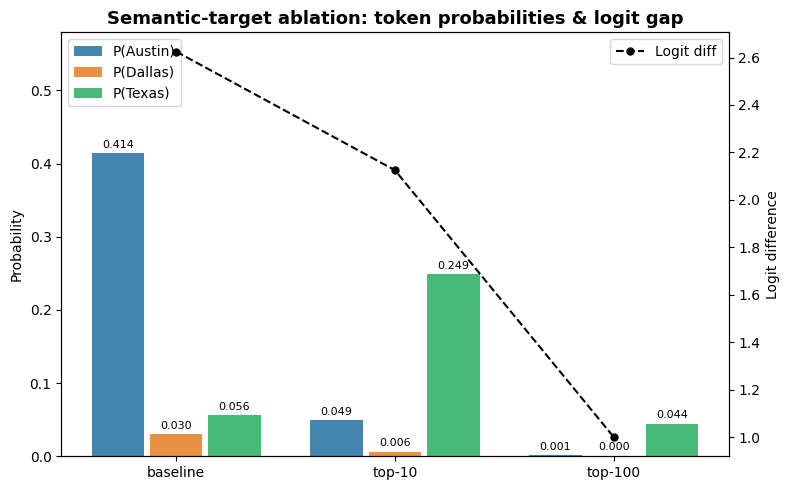


Top-100 semantic ablation — full prediction shift:


Token,Probability,Distribution
Austin,0.414,41.4%
Texas,0.056,5.6%
the,0.056,5.6%
not,0.056,5.6%
Fort,0.044,4.4%
Token,Probability,Distribution
the,0.154,15.4%
not,0.106,10.6%
called,0.064,6.4%
a,0.057,5.7%


In [14]:
# Progressive ablation of semantic-target features
sem_groups = {"baseline": {
    "P(Austin)": probs_base[idx_x].item(),
    "P(Dallas)": probs_base[idx_y].item(),
    "P(Texas)":  probs_base[idx_texas].item(),
}}
sem_logit_diffs = {"baseline": orig_gap}

sem_ablation_results = {}
for n in [10, 100]:
    top_n, _ = get_top_features(graph_semantic, n=n)
    abl_tuples = [
        (layer, pos, feat_idx, 0.0 * activations[layer, pos, feat_idx])
        for (layer, pos, feat_idx) in top_n
    ]
    abl_logits, _ = model.feature_intervention(input_ids, abl_tuples)
    probs_abl = torch.softmax(abl_logits.squeeze(0)[-1].float(), dim=-1)
    gap = (abl_logits.squeeze(0)[-1, idx_x] - abl_logits.squeeze(0)[-1, idx_y]).item()
    label = f"top-{n}"
    sem_groups[label] = {
        "P(Austin)": probs_abl[idx_x].item(),
        "P(Dallas)": probs_abl[idx_y].item(),
        "P(Texas)":  probs_abl[idx_texas].item(),
    }
    sem_logit_diffs[label] = gap
    sem_ablation_results[n] = abl_logits

display_ablation_chart(sem_groups, logit_diffs=sem_logit_diffs,
                       title="Semantic-target ablation: token probabilities & logit gap")

# Show the full top-k comparison for the strongest ablation
strongest_n = max(sem_ablation_results.keys())
print(f"\nTop-{strongest_n} semantic ablation — full prediction shift:")
display_topk(prompt, original_logits, sem_ablation_results[strongest_n])

## Visualize the Semantic Concept Graph

Save the **semantic concept** graph and serve it locally. The interactive visualization shows the circuit driving the abstract `Capitals − States` direction — the multi-hop reasoning path.

**If running on a remote server, set up port forwarding so that port 8046 is accessible on your local machine.**

In [15]:
from pathlib import Path

graph_dir = Path("attribution_targets_demo/graphs")
graph_dir.mkdir(parents=True, exist_ok=True)
graph_path = graph_dir / "dallas_austin_semantic_concept_graph.pt"
graph_semantic.to_pt(graph_path)

slug = "dallas-austin-semantic-concept"
graph_file_dir = "attribution_targets_demo/graph_files"
node_threshold, edge_threshold = 0.8, 0.98

create_graph_files(
    graph_or_path=graph_path,
    slug=slug,
    output_path=graph_file_dir,
    node_threshold=node_threshold,
    edge_threshold=edge_threshold,
)

In [16]:
from circuit_tracer.frontend.local_server import serve

port = 8046
server = serve(data_dir="attribution_targets_demo/graph_files/", port=port)

if IN_COLAB:
    from google.colab import output as colab_output  # noqa
    colab_output.serve_kernel_port_as_iframe(
        port, path="/index.html", height="800px", cache_in_notebook=True
    )
else:
    from IPython.display import IFrame
    print(f"Open your graph at: http://localhost:{port}/index.html")
    display(IFrame(src=f"http://localhost:{port}/index.html", width="100%", height="800px"))

Open your graph at: http://localhost:8046/index.html


In [ ]:
# server.stop()

: 